# YOLO

---

In [ ]:
import zipfile
import os

# Path to your ZIP file
zip_path = "/content/labels.zip"

# Folder where you want to extract the contents
extract_to = "/content/labels"

# Create the folder if it doesn't exist
os.makedirs(extract_to, exist_ok=True)

# Extracting the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"✅ Extracted '{zip_path}' to '{extract_to}'")

✅ Extracted '/content/labels.zip' to '/content/labels'


In [ ]:
import os

def print_directory_structure(root_dir, indent=""):
    for item in sorted(os.listdir(root_dir)):
        path = os.path.join(root_dir, item)
        if os.path.isdir(path):
            print(f"{indent}📁 {item}/")
            print_directory_structure(path, indent + "    ")
        else:
            print(f"{indent}📄 {item}")

# Change this to your project folder path
root_directory = "/content/labels"  # current directory or provide full path
print(f"Directory structure of: {os.path.abspath(root_directory)}\n")
print_directory_structure(root_directory)

Directory structure of: /content/labels

📄 B1.txt
📄 B10.txt
📄 B2.txt
📄 B3.txt
📄 B4.txt
📄 B5.txt
📄 B6.txt
📄 B7.txt
📄 B8.txt
📄 B9.txt
📄 H1.txt
📄 H10.txt
📄 H2.txt
📄 H3.txt
📄 H4.txt
📄 H5.txt
📄 H6.txt
📄 H7.txt
📄 H8.txt
📄 H9.txt


In [ ]:
import os
import shutil
import random
from pathlib import Path

# Original image and label dirs
image_root = '/content/Hrithik-Vs-Bradly'
label_root = '/content/labels'

# Output structure
output_dir = '/content/dataset'
img_out_dir = os.path.join(output_dir, 'images')
lbl_out_dir = os.path.join(output_dir, 'labels')

# Create required folders
for split in ['train', 'val']:
    os.makedirs(os.path.join(img_out_dir, split), exist_ok=True)
    os.makedirs(os.path.join(lbl_out_dir, split), exist_ok=True)

# Gather all image paths from both subfolders (Hritik, Bradly)
image_paths = []
for folder in ['Hritik', 'Bradly']:
    full_folder_path = os.path.join(image_root, folder)
    image_paths.extend([
        os.path.join(full_folder_path, f)
        for f in os.listdir(full_folder_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))
    ])

# Shuffle and split (80% train, 20% val)
random.seed(42)
random.shuffle(image_paths)
split_idx = int(0.8 * len(image_paths))
train_images = image_paths[:split_idx]
val_images = image_paths[split_idx:]

# Function to move image and corresponding label
def move_data(image_list, split):
    for img_path in image_list:
        fname = Path(img_path).stem
        ext = Path(img_path).suffix
        label_path = os.path.join(label_root, f"{fname}.txt")

        if os.path.exists(label_path):
            # Copy image
            shutil.copy(img_path, os.path.join(img_out_dir, split, fname + ext))
            # Copy label
            shutil.copy(label_path, os.path.join(lbl_out_dir, split, f"{fname}.txt"))

# Move files
move_data(train_images, 'train')
move_data(val_images, 'val')

print("✅ Dataset reorganized successfully!")

✅ Dataset reorganized successfully!


In [ ]:
from google.colab import files
import shutil

folder_path = '/content/dataset'  # The folder you want to download
zip_path = '/content/dataset.zip'  # The output zip file path

# Compress the folder into a zip file
shutil.make_archive(base_name=zip_path.replace('.zip', ''), format='zip', root_dir=folder_path)

# Download the zip file
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install ultralytics
!pip install -U ultralytics huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 65.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [ ]:
!yolo detect train data=/content/dataset/data.yaml model=yolov8n.pt epochs=20 imgsz=640

Ultralytics 8.3.134 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True


image 1/1 /content/dataset/images/val/H2.jpeg: 640x384 (no detections), 161.7ms
Speed: 6.0ms preprocess, 161.7ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 384)


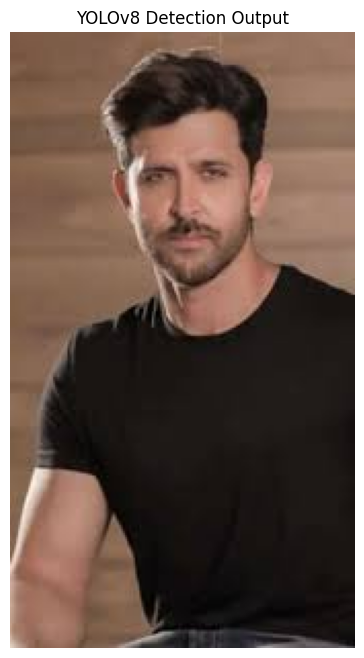

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load your trained YOLOv8 model
model = YOLO("/content/runs/detect/train7/weights/best.pt")  # update path if needed

# Path to the image or folder of images
image_path = "/content/dataset/images/val/H2.jpeg"  # single image or folder

# Run inference
results = model(image_path)

# Iterate over results and display predictions
for result in results:
    # r.plot() returns an image (numpy array) with bounding boxes drawn
    img_with_boxes = result.plot()

    # Convert from BGR (OpenCV) to RGB (Matplotlib)
    img_rgb = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("YOLOv8 Detection Output")
    plt.show()

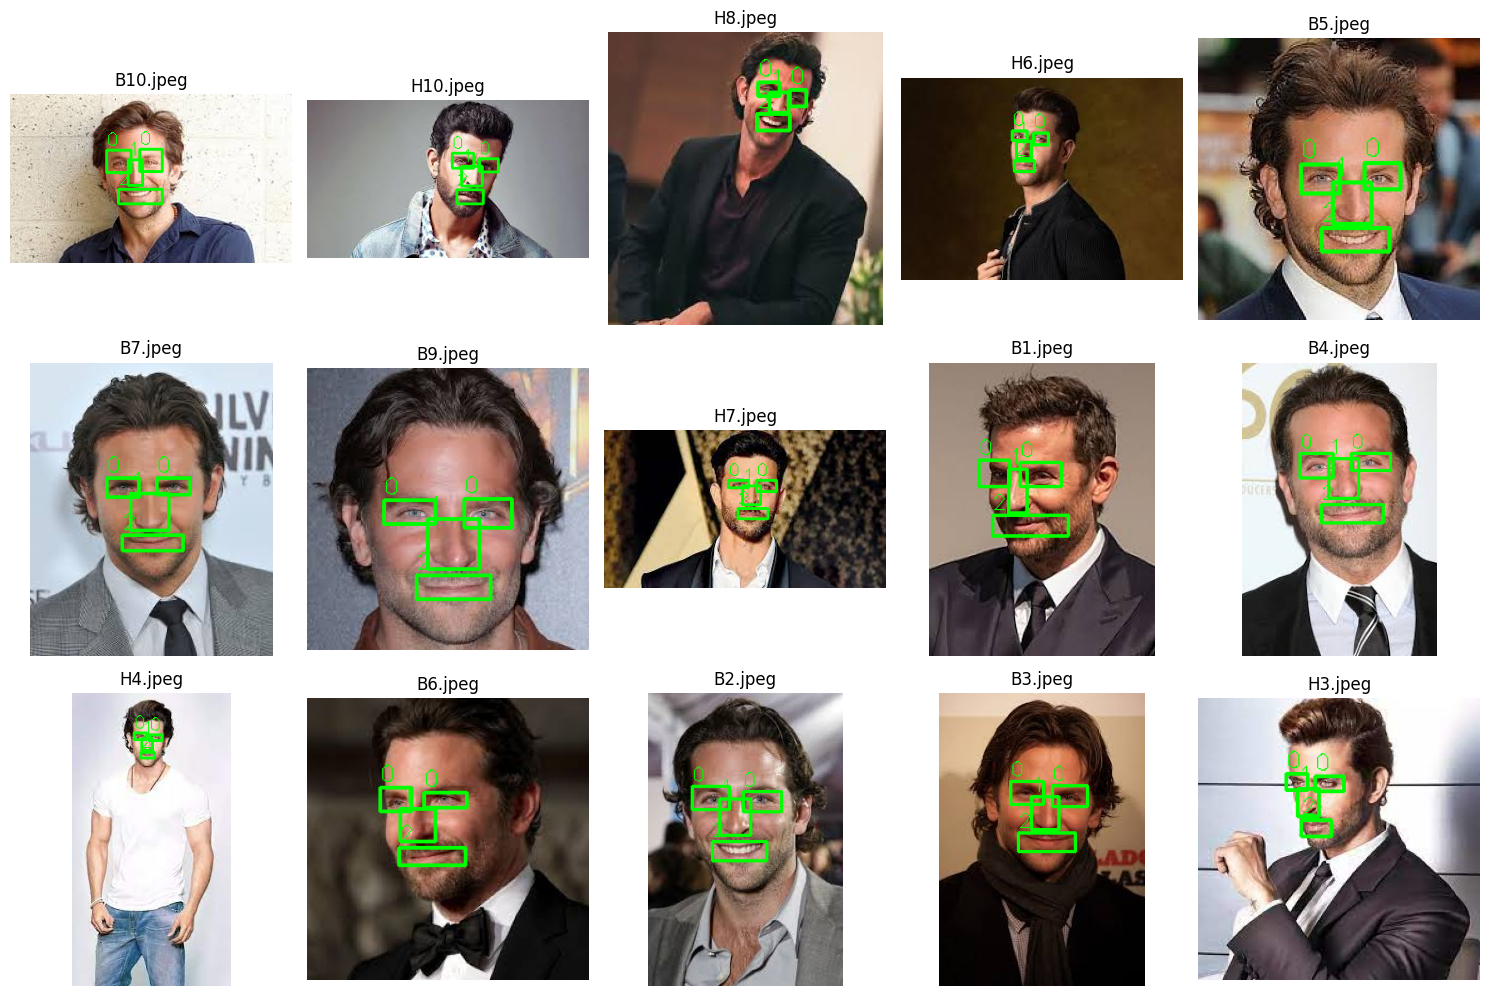

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

img_dir = '/content/dataset/images/train'  # or val images
label_dir = '/content/dataset/labels/train'  # or val labels

images = []
image_names = []

for img_name in os.listdir(img_dir):
    if not img_name.lower().endswith(('.jpg', '.png', '.jpeg', 'webp')):
        continue
    img_path = os.path.join(img_dir, img_name)
    label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + '.txt')
    if not os.path.exists(label_path):
        continue

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:
        cls, cx, cy, bw, bh = map(float, line.strip().split())
        x1 = int((cx - bw / 2) * w)
        y1 = int((cy - bh / 2) * h)
        x2 = int((cx + bw / 2) * w)
        y2 = int((cy + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, str(int(cls)), (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 1)

    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img_rgb)
    image_names.append(img_name)

    # Stop after collecting 12 images to avoid huge output
    if len(images) >= 50:
        break

# Plot images in a grid: 3 rows x 4 columns
rows, cols = 3, 5
fig, axs = plt.subplots(rows, cols, figsize=(15, 10))
axs = axs.flatten()

for i, ax in enumerate(axs):
    if i < len(images):
        ax.imshow(images[i])
        ax.set_title(image_names[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

---
# Semantic_Segmentation


---



In [ ]:
!pip install tensorflow opencv-python matplotlib

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def unet(input_size=(128, 128, 1)):
    inputs = tf.keras.Input(input_size)

    # Encoding path
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)

    # Decoding path
    u1 = layers.UpSampling2D()(c3)
    u1 = layers.concatenate([u1, c2])
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.concatenate([u2, c1])
    c5 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c5)

    model = models.Model(inputs, outputs)
    return model

model = unet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_6[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │         17 │ conv2d_7[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 106,417 (415.69 KB)

 Trainable params: 106,417 (415.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import cv2
import numpy as np

def load_and_preprocess_image(image_path, target_size=(128,128)):
    # Read image as grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Resize to target size
    img = cv2.resize(img, target_size)

    # Normalize pixel values (0-255 to 0-1)
    img = img.astype(np.float32) / 255.0

    # Expand dims to add channel (batch, height, width, channels)
    img = np.expand_dims(img, axis=-1)   # add channel
    img = np.expand_dims(img, axis=0)    # add batch

    return img

# Usage example:
input_image = load_and_preprocess_image('/content/dataset/images/val/H9.jpeg')

# Now feed this into the model for prediction
pred_mask = model.predict(input_image)

print("Prediction mask shape:", pred_mask.shape)  # Should be (1, 128, 128, 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step
Prediction mask shape: (1, 128, 128, 1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


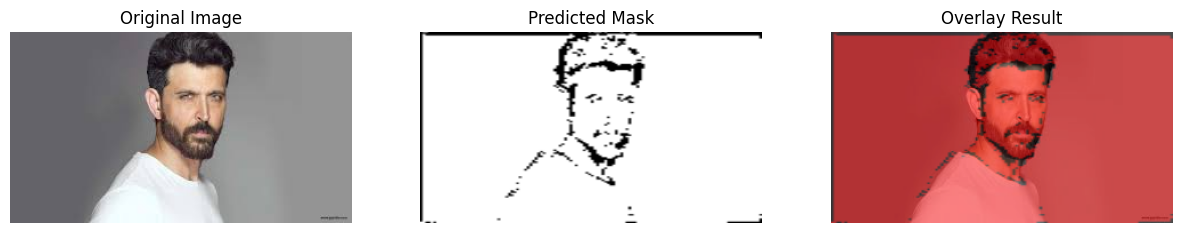

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def load_and_preprocess_image(image_path, target_size=(128,128)):
    # Read original image in color (for overlay later)
    orig_img = cv2.imread(image_path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for display

    # Read grayscale for model input
    img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_gray = cv2.resize(img_gray, target_size)
    img_gray = img_gray.astype(np.float32) / 255.0
    img_gray = np.expand_dims(img_gray, axis=-1)  # add channel
    img_gray = np.expand_dims(img_gray, axis=0)   # add batch

    return orig_img, img_gray

def postprocess_mask(pred_mask, threshold=0.5):
    # Remove batch and channel dimensions: (1, 128,128,1) -> (128,128)
    mask = pred_mask[0, :, :, 0]

    # Threshold to create binary mask
    binary_mask = (mask > threshold).astype(np.uint8) * 255

    return binary_mask

def overlay_mask_on_image(image, mask, color=(255,0,0), alpha=0.5):
    overlay = image.copy()
    colored_mask = np.zeros_like(image)
    for i in range(3):
        colored_mask[:, :, i] = (mask / 255) * color[i]

    # Blend original image and colored mask
    cv2.addWeighted(colored_mask.astype(np.uint8), alpha, overlay, 1 - alpha, 0, overlay)
    return overlay

# Load image and preprocess
image_path = '/content/dataset/images/val/H9.jpeg'
orig_img, input_img = load_and_preprocess_image(image_path)

# Predict mask
pred_mask = model.predict(input_img)

# Post-process prediction mask
binary_mask = postprocess_mask(pred_mask, threshold=0.5)

# Resize mask to original image size for overlay
binary_mask_resized = cv2.resize(binary_mask, (orig_img.shape[1], orig_img.shape[0]))

# Overlay mask on original image
result_img = overlay_mask_on_image(orig_img, binary_mask_resized, color=(255, 0, 0), alpha=0.5)

# Show results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title('Original Image')
plt.axis('off')
plt.imshow(orig_img)

plt.subplot(1,3,2)
plt.title('Predicted Mask')
plt.axis('off')
plt.imshow(binary_mask_resized, cmap='gray')

plt.subplot(1,3,3)
plt.title('Overlay Result')
plt.axis('off')
plt.imshow(result_img)

plt.show()

---
# RNN
---

In [ ]:
import zipfile
import os

# Path to your ZIP file
zip_path = "/content/Twitter-dataset.zip"

# Folder where you want to extract the contents
extract_to = "/content/Twitter-dataset"

# Create the folder if it doesn't exist
os.makedirs(extract_to, exist_ok=True)

# Extracting the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"✅ Extracted '{zip_path}' to '{extract_to}'")

✅ Extracted '/content/Twitter-dataset.zip' to '/content/Twitter-dataset'


In [ ]:
import pandas as pd
import numpy as np
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Load your dataset - update the path to your CSV file
df = pd.read_csv('/content/Twitter-dataset/tweets_dataset.csv')

# Check columns
print("Columns:", df.columns)

# If clean_tweet is missing, create it by simple cleaning from tweet
if 'clean_tweet' not in df.columns:
    print("clean_tweet column missing - creating it now...")
    def simple_clean(text):
        text = text.lower()
        text = re.sub(r'http\S+', '', text)  # remove URLs
        text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation/numbers
        text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
        return text
    df['clean_tweet'] = df['tweet'].astype(str).apply(simple_clean)

# Prepare inputs and labels
texts = df['clean_tweet'].values
labels = df['is_real'].values  # Make sure this is binary 0/1

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

# Tokenize text
max_vocab_size = 10000
tokenizer = Tokenizer(num_words=max_vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert texts to sequences
train_seq = tokenizer.texts_to_sequences(X_train)
test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
max_seq_len = 50
X_train_pad = pad_sequences(train_seq, maxlen=max_seq_len, padding='post', truncating='post')
X_test_pad = pad_sequences(test_seq, maxlen=max_seq_len, padding='post', truncating='post')

# Build simple RNN model
embedding_dim = 64

model = Sequential([
    Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_seq_len),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Explicitly build the model so summary shows real param counts
model.build(input_shape=(None, max_seq_len))
print(model.summary())

# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
history = model.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_split=0.1)

# Predict and evaluate
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Print predicted and actual labels side by side (first 20 samples)
print("\nActual vs Predicted for first 20 test samples:")
for actual, pred in list(zip(y_test, y_pred))[:20]:
    print(f"Actual: {actual}, Predicted: {pred[0]}")

Columns: Index(['name', 'tweet', 'is_real'], dtype='object')
clean_tweet column missing - creating it now...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,321 (2.47 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 243ms/step - accuracy: 0.4221 - loss: 0.7348 - val_accuracy: 0.7000 - val_loss: 0.6900
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7976 - loss: 0.6119 - val_accuracy: 0.8000 - val_loss: 0.6011
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9533 - loss: 0.4429 - val_accuracy: 0.9000 - val_loss: 0.4175
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9591 - loss: 0.2597 - val_accuracy: 0.9000 - val_loss: 0.3467
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9825 - loss: 0.1962 - val_accuracy: 0.9000 - val_loss: 0.3202
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Test Accuracy: 0.9583333333333334
              precision    recall  f1-score   support

       False       0.90      1.00      0.95         9
        True       1.00      0.93      0.97        15

    accuracy                           0.96        24
   macro avg       0.95      0.97      0.96        24
weighted avg       0.96      